# HistGradientBoosting: trening, validering og test

Ikke-lineær hovedmodell med samme feature-kandidater som Ridge. Håndterer NaN; helt tomme/konstante kolonner fjernes fra hver treningsperiode. Antall blad velges på valideringen.

Trening sammenlignes for 2022–24 og bare 2023–24, validering er 2024–25. Vinneren velges etter RMSE, så refittes den med 2024–25 inkludert og evalueres på 2025–26. MAE, bias og rangering rapporteres også. Ingen testbasert tuning.

2025–26 er tidligere undersøkt i utforskningsnotebooken: dette er en historisk holdout, ikke en helt urørt bekreftelse. 2026–27 er utelatt. Alle spillerobservasjoner, også null minutter, beholdes; Assistant Managers utelates.

**Tidspunkt:** features er forskjøvet per kamp. SAFE i metadata betyr ikke nødvendigvis tilgjengelig før FPL-deadline. Resultatene gjelder kampvis prediksjon; deadline-backtesting krever historikk frosset før hver deadline.

Kjør med prosjektets .venv. Felles kode i src/model_experiments.py sørger for samme sikkerhetsregler og metrikker i alle tre notebooks.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/model_experiments.py').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
from model_experiments import *
KIND = 'hgb'
pd.set_option('display.max_columns', 20)
data, metadata = load_data(ROOT)
display(data.groupby('season').agg(rows=(TARGET, 'size'), gameweeks=('GW', 'nunique'), mean_points=(TARGET, 'mean')))
print('Kjerne:', len(CORE), 'Fotball:', len(FEATURE_SETS['football']), 'Kampkontekst:', len(FEATURE_SETS['context']))


,rows,gameweeks,mean_points
season,,,
2020-21,24365,38,1.290704
2021-22,25447,38,1.234487
2022-23,26505,37,1.196906
2023-24,29725,38,1.052010
2024-25,27283,38,1.146868
2025-26,29747,38,1.155814
2026-27,610,1,1.554098


Kjerne: 17 Fotball: 26 Kampkontekst: 34


## Datadekning i treningsperioden

SAFE-features + eksplisitt godkjente position/was_home er tillatt. ID-er brukes til gruppering. Markedsdata, xP og nåværende kamputfall er utelatt fra X. Manglende statistikk betyr ikke null prestasjon. Nyere defensive-contribution-felt tas ikke med fordi treningssesongene mangler målingene.


In [2]:
train_audit = data[data.season.isin(['2022-23', '2023-24'])]
coverage = train_audit[FEATURE_SETS['context']].isna().mean().sort_values(ascending=False).rename('missing_fraction')
display(coverage.to_frame())
season_coverage = train_audit.groupby('season')[FEATURE_SETS['context']].agg(lambda x: x.notna().mean())
display(season_coverage.T)


,missing_fraction
xA90_last5,0.470852
xG90_last5,0.470852
minutes_last1,0.029219
creativity_avg5,0.029219
saves_avg5,0.029219
clean_sheet_rate5,0.029219
assists_last5,0.029219
goals_last5,0.029219
xA_last5,0.029219
xG_last5,0.029219


season,2022-23,2023-24
minutes_last1,0.970647,0.970900
minutes_avg3,0.970647,0.970900
minutes_avg5,0.970647,0.970900
minutes_avg10,0.970647,0.970900
games_60plus_last3,0.970647,0.970900
games_available_last5,1.000000,1.000000
games_played_season_before,1.000000,1.000000
points_avg3,0.970647,0.970900
points_avg5,0.970647,0.970900
points_avg10,0.970647,0.970900


## Modellvalg på 2024–25

Core bruker spilletid og FPL/ICT-form. Football legger til underliggende angrep og keeper/forsvar; context legger til lag og motstander. Vi tester hele treningsutvalget, med samme evaluering for alle varianter. RMSE prioriteres fordi modellen skal anslå forventede poeng; MAE alene favoriserer medianen ved skjeve poengfordelinger.


hgb: ferdig med trening ('2022-23', '2023-24')


hgb: ferdig med trening ('2023-24',)


,train_seasons,feature_set,parameter,n_features,dropped,MAE,RMSE,Spearman,bias,actual_mean,predicted_mean
0,2022-23|2023-24,context,7,34,,1.0079,1.9282,0.6996,0.0062,1.1469,1.1531
1,2022-23|2023-24,context,15,34,,1.0084,1.9314,0.7010,0.0084,1.1469,1.1553
2,2023-24,context,7,34,,1.0083,1.9339,0.6980,-0.0026,1.1469,1.1443
3,2023-24,context,15,34,,1.0099,1.9366,0.6986,0.0006,1.1469,1.1475
4,2023-24,football,7,26,,1.0063,1.9378,0.7008,-0.0105,1.1469,1.1364
5,2022-23|2023-24,football,7,26,,1.0101,1.9381,0.7014,-0.0006,1.1469,1.1463
6,2022-23|2023-24,football,15,26,,1.0089,1.9400,0.7016,-0.0045,1.1469,1.1424
7,2023-24,football,15,26,,1.0058,1.9402,0.7005,-0.0101,1.1469,1.1368
8,2022-23|2023-24,core,7,17,,1.0113,1.9403,0.7005,0.0002,1.1469,1.1471
9,2023-24,core,7,17,,1.0070,1.9429,0.6986,-0.0120,1.1469,1.1348


Valgt før holdout: {'train_seasons': '2022-23|2023-24', 'feature_set': 'context', 'parameter': 7, 'n_features': 34, 'dropped': '', 'MAE': 1.007937511782679, 'RMSE': 1.9281956719988478, 'Spearman': 0.6996124152765728, 'bias': 0.006242833544609232, 'actual_mean': 1.1468680130484183, 'predicted_mean': 1.1531108465930278}


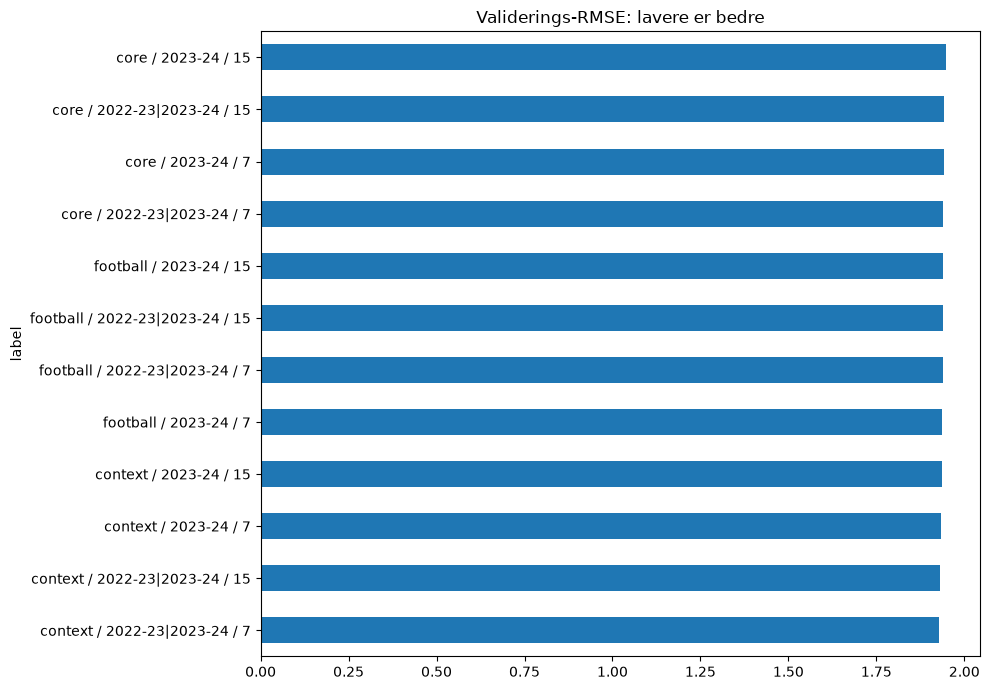

In [3]:
validation_results = search(KIND, data)
display(validation_results.round(4))
best = validation_results.iloc[0].to_dict()
print('Valgt før holdout:', best)
validation_results[['feature_set', 'train_seasons', 'parameter', 'RMSE']].assign(
    label=lambda x: x.feature_set + ' / ' + x.train_seasons + ' / ' + x.parameter.astype(str)
).plot.barh(x='label', y='RMSE', figsize=(10, 7), legend=False)
plt.title('Validerings-RMSE: lavere er bedre'); plt.tight_layout()


## Refit og historisk holdout 2025–26

Valideringsvinnerens treningsperiode utvides med 2024–25. Preprosesseringen tilpasses på nytt med disse treningsradene. Featurevalg og hyperparametre skal ikke endres som følge av holdout-resultatet.


In [4]:
model, model_features, dropped, predictions = refit(KIND, data, best)
display(pd.DataFrame([metrics(predictions[TARGET], predictions.prediction)]).round(4))
print('Features:', len(model_features), 'Droppet ved refit:', dropped)
for column in ['position', 'minutes_group', 'GW']:
    print(column)
    display(grouped_metrics(predictions, column).round(4))


,MAE,RMSE,Spearman,bias,actual_mean,predicted_mean
0,0.9686,1.9359,0.7132,-0.0862,1.1558,1.0696


Features: 34 Droppet ved refit: []
position


,group,n,MAE,RMSE,Spearman,bias,actual_mean,predicted_mean
0,DEF,9733,1.1129,2.1265,0.6578,-0.1710,1.2368,1.0658
1,FWD,3278,1.0585,2.0635,0.7678,-0.0416,1.2828,1.2412
2,GK,3427,0.6084,1.4061,0.6587,0.0101,0.7482,0.7583
3,MID,13309,0.9337,1.8740,0.7330,-0.0600,1.1703,1.1103


minutes_group


,group,n,MAE,RMSE,Spearman,bias,actual_mean,predicted_mean
0,0,18255,0.3345,0.7096,-0.0066,0.3345,-0.0001,0.3345
1,1–59,3679,1.1506,1.6567,0.0295,0.2952,1.2283,1.5235
2,60+,7813,2.3644,3.4352,0.1034,-1.2488,3.8223,2.5735


GW


,group,n,MAE,RMSE,Spearman,bias,actual_mean,predicted_mean
0,1,690,1.6859,2.5416,0.0088,-0.1683,1.3942,1.2259
1,2,705,1.1018,2.2288,0.6634,-0.1309,1.2837,1.1528
2,3,712,1.0596,2.0024,0.7155,-0.1914,1.3076,1.1162
3,4,740,1.0828,2.0328,0.6854,-0.2180,1.3149,1.0969
4,5,741,0.9373,1.8228,0.7105,-0.0155,1.1242,1.1086
5,6,742,0.9335,1.9126,0.7211,-0.0057,1.1186,1.1129
6,7,743,0.9476,1.8661,0.7432,-0.0916,1.2100,1.1184
7,8,745,0.9854,2.0476,0.7454,-0.1334,1.2456,1.1122
8,9,746,0.9485,1.9832,0.7492,-0.1277,1.2198,1.0922
9,10,747,0.9382,1.8599,0.7609,-0.0828,1.1874,1.1046


## Kalibrering og rangering

Faktisk spilletid brukes bare til etterfølgende feilrapportering. Topp-k summerer kampene per spiller/gameweek og inkluderer en fasitbasert øvre grense. Dette er en retrospektiv diagnose, ikke simulering av et lovlig FPL-lag eller av deadline-valg. Blanke gameweeks uten rader inngår ikke.


,selected_mean_points,oracle_mean_points,regret_per_player
k,,,
10,4.897,12.913,8.016
25,4.299,10.571,6.272
50,4.029,8.579,4.549


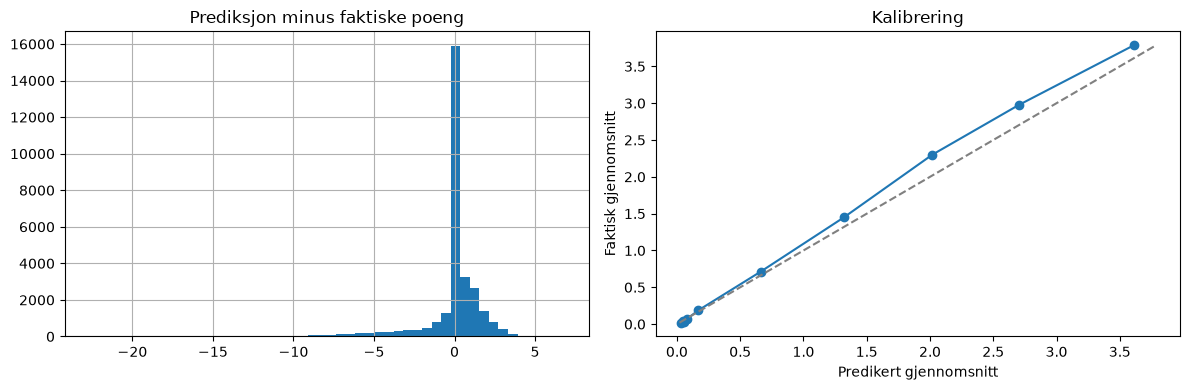

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
predictions.error.hist(bins=50, ax=axes[0])
axes[0].set_title('Prediksjon minus faktiske poeng')
calibration = predictions.assign(bin=pd.qcut(predictions.prediction, 10, duplicates='drop')).groupby('bin', observed=True)[[TARGET, 'prediction']].mean()
if len(calibration):
    axes[1].plot(calibration.prediction, calibration[TARGET], 'o-')
    bounds = [min(calibration.min()), max(calibration.max())]
    axes[1].plot(bounds, bounds, '--', color='grey')
axes[1].set(xlabel='Predikert gjennomsnitt', ylabel='Faktisk gjennomsnitt', title='Kalibrering')
plt.tight_layout()
top_k = ranking(predictions)
display(top_k.groupby('k')[['selected_mean_points', 'oracle_mean_points', 'regret_per_player']].mean().round(3))


## Permutasjonsviktighet på valideringen

Vi trener en separat kopi på utviklingsperioden for å forklare den valgte modellen. Viktigheten beregnes på et fast utvalg fra 2024–25; korrelerte features kan erstatte hverandre. Holdout brukes ikke til dette.


In [6]:
from sklearn.inspection import permutation_importance
tr, va = split(data, best['train_seasons'].split('|'), '2024-25')
explain_model, explain_cols, _, _ = fit_predict(KIND, tr, va, best['feature_set'], int(best['parameter']))
sample = va.sample(min(3000, len(va)), random_state=42)
with threadpool_limits(limits=4):
    importance = permutation_importance(explain_model, sample[explain_cols], sample[TARGET],
        scoring='neg_mean_squared_error', n_repeats=3, random_state=42, n_jobs=1)
display(pd.DataFrame({'feature': explain_cols, 'MSE_increase': importance.importances_mean,
    'std': importance.importances_std}).sort_values('MSE_increase', ascending=False).head(25))


,feature,MSE_increase,std
0,minutes_last1,1.047815,0.050631
9,points_avg10,0.073855,0.019716
1,minutes_avg3,0.024988,0.004150
31,opp_points_per_game_before,0.016755,0.003524
28,opp_goals_for_per_game_before,0.016132,0.002076
14,influence_avg5,0.011142,0.002012
21,xA_last5,0.007153,0.000861
27,team_goals_against_per_game_before,0.006310,0.002665
8,points_avg5,0.005901,0.002713
3,minutes_avg10,0.004623,0.001707


## Lagre kjøringen

En ny mappe per kjøring inneholder modellen med inputkolonner, valideringsresultater, testprediksjoner, metrikker og innstillinger. Sammenlign først valideringsresultatene fra de tre notebookene. Pris/budsjett, skader og historiske deadline-snapshots krever senere utvidelser.


In [7]:
output_dir = save_run(ROOT, KIND, model, model_features, validation_results, predictions)
print('Lagret:', output_dir)
comparison = []
for manifest_path in sorted((ROOT / 'artifacts/models').glob('*/manifest.json')):
    manifest = json.loads(manifest_path.read_text())
    comparison.append({'run': manifest_path.parent.name, 'model': manifest['model'],
        'validation_RMSE': manifest['best_validation']['RMSE'],
        'validation_MAE': manifest['best_validation']['MAE']})
display(pd.DataFrame(comparison).sort_values('validation_RMSE'))


Lagret: /Users/henrik/Documents/fplmodell/artifacts/models/hgb_5qmx900m


,run,model,validation_RMSE,validation_MAE
4,ridge_2t8ef6ry,ridge,1.926475,1.035325
5,ridge_88l8gwyt,ridge,1.926475,1.035325
2,hgb_5qmx900m,hgb,1.928196,1.007938
3,hgb_ghlb0yfj,hgb,1.928196,1.007938
0,dummy_1c3ntmar,dummy,2.310832,1.435675
1,dummy_yv8w1w91,dummy,2.310832,1.435675
